In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [2]:
b = pd.read_csv('./data/joint/23-24/merged_player_data.csv')
# b[b['event']]
b['event'].max()

38

In [3]:
gw=35
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]

# data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [5]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    293
1     70
Name: count, dtype: int64


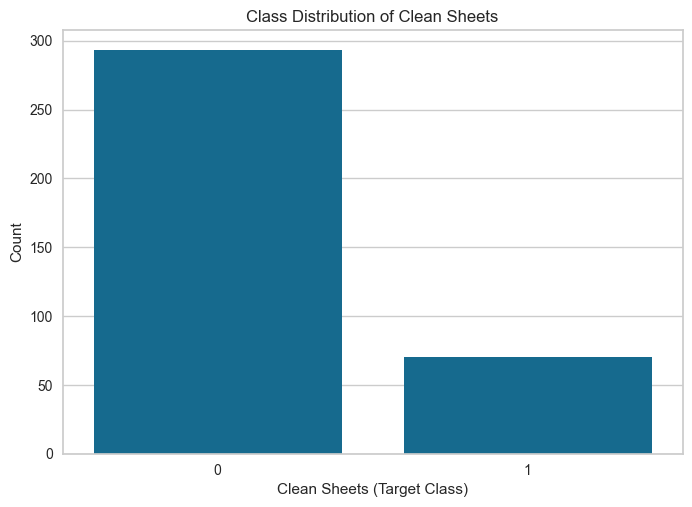

In [6]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [7]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 192, number of negative: 192
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.163161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3677
[LightGBM] [Info] Number of data points in the train set: 384, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(363, 73)"
4,Transformed data shape,"(493, 15)"
5,Transformed train set shape,"(384, 15)"
6,Transformed test set shape,"(109, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [8]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5822,0.5992,0.5000,0.2129,0.2959,0.0537,0.0745,0.4060
ridge,Ridge Classifier,0.5862,0.5972,0.5000,0.2152,0.2981,0.0576,0.0786,0.5580
lr,Logistic Regression,0.5785,0.5964,0.4800,0.2047,0.2846,0.0395,0.0578,1.5370
nb,Naive Bayes,0.5752,0.5785,0.5200,0.2199,0.3069,0.0626,0.0815,0.3560
knn,K Neighbors Classifier,0.5117,0.5625,0.6950,0.2330,0.3469,0.0876,0.1310,0.3240
qda,Quadratic Discriminant Analysis,0.7051,0.5611,0.3050,0.2786,0.2778,0.1008,0.1045,0.3870
ada,Ada Boost Classifier,0.6458,0.5451,0.3550,0.2154,0.2660,0.0525,0.0541,0.4400
et,Extra Trees Classifier,0.7043,0.5026,0.0600,0.0567,0.0582,-0.0942,-0.1016,0.6390
dummy,Dummy Classifier,0.8071,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3730
lightgbm,Light Gradient Boosting Machine,0.6929,0.4908,0.1200,0.1069,0.1119,-0.0612,-0.0626,0.4690


In [9]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [10]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6538,0.5714,0.2000,0.1667,0.1818,-0.0354,-0.0356
1,0.5385,0.5905,0.4000,0.1818,0.2500,-0.0196,-0.0228
2,0.6538,0.6571,1.0000,0.3571,0.5263,0.3390,0.4518
3,0.5385,0.5524,0.4000,0.1818,0.2500,-0.0196,-0.0228
4,0.6400,0.5357,0.0000,0.0000,0.0000,-0.2162,-0.2182
5,0.6000,0.6100,0.6000,0.2727,0.3750,0.1379,0.1612
6,0.6000,0.7300,0.6000,0.2727,0.3750,0.1379,0.1612
7,0.4000,0.4800,0.4000,0.1429,0.2105,-0.1194,-0.1612
8,0.6400,0.8800,1.0000,0.3571,0.5263,0.3284,0.4432


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [11]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [12]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## DEF


clean_sheets
0    1148
1     285
Name: count, dtype: int64


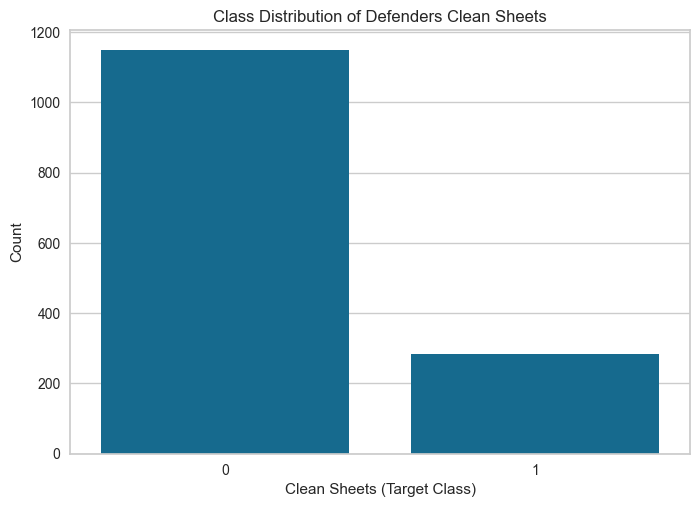

In [13]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [14]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 765, number of negative: 765
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13500
[LightGBM] [Info] Number of data points in the train set: 1530, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1433, 73)"
4,Transformed data shape,"(1960, 15)"
5,Transformed train set shape,"(1530, 15)"
6,Transformed test set shape,"(430, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [15]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.7966,0.7511,0.3068,0.4653,0.3648,0.2534,0.2622,0.8680
et,Extra Trees Classifier,0.7995,0.7368,0.3166,0.4833,0.3795,0.2685,0.2775,1.3770
lightgbm,Light Gradient Boosting Machine,0.7946,0.7352,0.2818,0.4607,0.3456,0.2352,0.2457,2.3700
rf,Random Forest Classifier,0.7926,0.7176,0.2961,0.4485,0.3540,0.2394,0.2467,1.4300
gbc,Gradient Boosting Classifier,0.7707,0.6835,0.2966,0.3922,0.3365,0.2023,0.2052,5.5520
knn,K Neighbors Classifier,0.5764,0.6558,0.6476,0.2668,0.3776,0.1345,0.1651,2.7150
ada,Ada Boost Classifier,0.6859,0.6485,0.4063,0.2873,0.3357,0.1376,0.1421,2.8970
ridge,Ridge Classifier,0.6002,0.6260,0.5529,0.2575,0.3504,0.1121,0.1326,0.9400
lr,Logistic Regression,0.6012,0.6259,0.5529,0.2586,0.3515,0.1137,0.1337,0.9680
lda,Linear Discriminant Analysis,0.6012,0.6247,0.5479,0.2570,0.3491,0.1109,0.1306,2.1000


In [16]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [17]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,23:34:27
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Extreme Gradient Boosting


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6832,0.7117,0.6000,0.3333,0.4286,0.2334,0.2527
1,0.7525,0.7636,0.5500,0.4074,0.4681,0.3114,0.3174
2,0.7327,0.7525,0.6000,0.3871,0.4706,0.3027,0.3157
3,0.7600,0.7602,0.6842,0.4194,0.5200,0.3721,0.3919
4,0.7900,0.7694,0.6500,0.4815,0.5532,0.4199,0.4280
5,0.7600,0.7912,0.7500,0.4412,0.5556,0.4059,0.4328
6,0.7400,0.7306,0.6000,0.4000,0.4800,0.3158,0.3273
7,0.6400,0.6075,0.4000,0.2500,0.3077,0.0816,0.0857
8,0.7400,0.7456,0.5500,0.3929,0.4583,0.2935,0.3007


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [18]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [19]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                importance_type=None,
                                interaction_cons

## MID


clean_sheets
0    1155
1     307
Name: count, dtype: int64


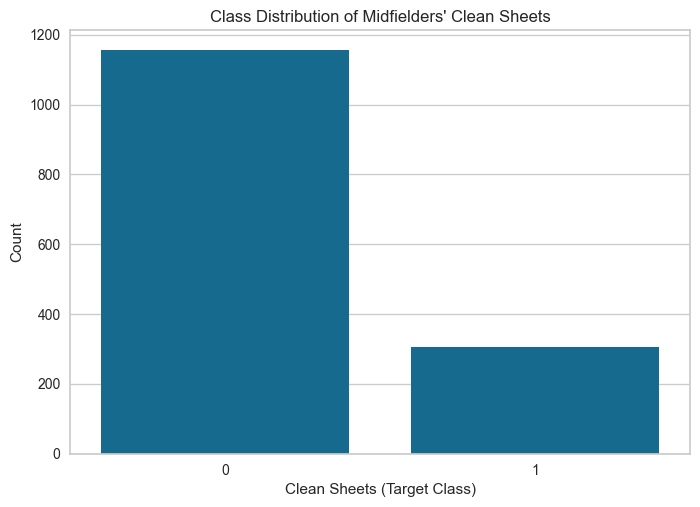

In [20]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [21]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 774, number of negative: 774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13844
[LightGBM] [Info] Number of data points in the train set: 1548, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1462, 73)"
4,Transformed data shape,"(1987, 15)"
5,Transformed train set shape,"(1548, 15)"
6,Transformed test set shape,"(439, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [22]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7556,0.6623,0.2229,0.3647,0.2742,0.1389,0.1455,2.4170
rf,Random Forest Classifier,0.7576,0.6572,0.2234,0.3854,0.2802,0.1462,0.1558,1.1070
lightgbm,Light Gradient Boosting Machine,0.7790,0.6566,0.2781,0.4622,0.3453,0.2223,0.2338,1.1150
xgboost,Extreme Gradient Boosting,0.7644,0.6554,0.2511,0.3854,0.2989,0.1701,0.1756,1.5540
ridge,Ridge Classifier,0.6002,0.6377,0.5721,0.2779,0.3719,0.1275,0.1488,0.9110
lda,Linear Discriminant Analysis,0.6002,0.6365,0.5673,0.2768,0.3696,0.1251,0.1460,0.9500
lr,Logistic Regression,0.6051,0.6364,0.5721,0.2812,0.3748,0.1328,0.1540,0.6980
gbc,Gradient Boosting Classifier,0.7380,0.6139,0.1818,0.2934,0.2229,0.0778,0.0807,2.0210
knn,K Neighbors Classifier,0.5417,0.5892,0.6229,0.2570,0.3628,0.0939,0.1173,0.6850
qda,Quadratic Discriminant Analysis,0.6119,0.5848,0.4970,0.2679,0.3475,0.1046,0.1161,1.1610


In [23]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [24]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6408,0.6313,0.3182,0.2414,0.2745,0.0417,0.0424
1,0.6408,0.6829,0.6818,0.3333,0.4478,0.2256,0.2573
2,0.6408,0.6150,0.5909,0.3171,0.4127,0.1866,0.2053
3,0.6765,0.6502,0.5238,0.3235,0.4000,0.1951,0.2057
4,0.6569,0.6373,0.3810,0.2667,0.3137,0.0944,0.0970
5,0.6078,0.5620,0.4286,0.2432,0.3103,0.0646,0.0697
6,0.6078,0.4574,0.2381,0.1724,0.2000,-0.0510,-0.0522
7,0.7353,0.7184,0.4762,0.3846,0.4255,0.2561,0.2585
8,0.6961,0.7170,0.6818,0.3846,0.4918,0.2983,0.3232


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [25]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [26]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

# Yellow Cards


In [27]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    337
1     26
Name: count, dtype: int64


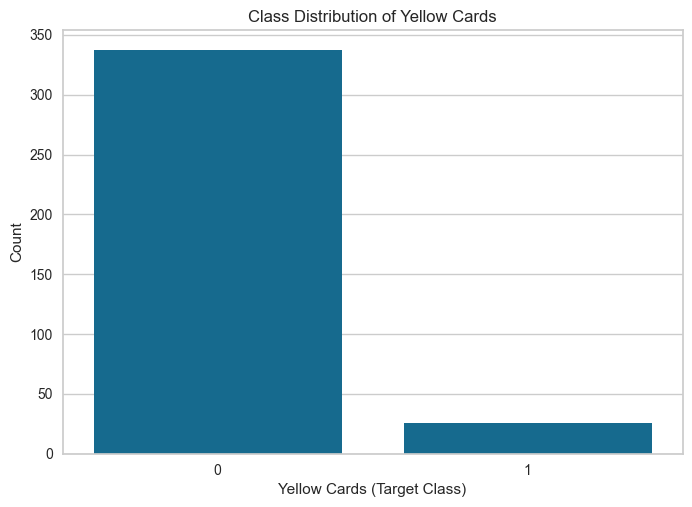

In [28]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [29]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 224, number of negative: 224
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4689
[LightGBM] [Info] Number of data points in the train set: 448, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(363, 75)"
4,Transformed data shape,"(557, 15)"
5,Transformed train set shape,"(448, 15)"
6,Transformed test set shape,"(109, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [30]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9054,0.6258,0.2500,0.2533,0.2067,0.1726,0.1937,0.6050
xgboost,Extreme Gradient Boosting,0.8935,0.6180,0.2500,0.2033,0.1900,0.1448,0.1616,0.4750
gbc,Gradient Boosting Classifier,0.8895,0.5788,0.2500,0.1450,0.1667,0.1194,0.1321,0.5290
rf,Random Forest Classifier,0.9172,0.5509,0.2000,0.2250,0.1733,0.1489,0.1675,0.4730
dt,Decision Tree Classifier,0.7986,0.5447,0.2500,0.0983,0.1371,0.0613,0.0672,0.3750
lda,Linear Discriminant Analysis,0.6732,0.5339,0.2500,0.0533,0.0879,-0.0269,-0.0287,0.3900
qda,Quadratic Discriminant Analysis,0.9215,0.5314,0.0000,0.0000,0.0000,-0.0108,-0.0115,0.3740
ridge,Ridge Classifier,0.6771,0.5274,0.2500,0.0547,0.0897,-0.0245,-0.0260,0.3150
lr,Logistic Regression,0.6734,0.5211,0.2500,0.0533,0.0879,-0.0268,-0.0286,0.4280
et,Extra Trees Classifier,0.9252,0.5142,0.1000,0.0333,0.0500,0.0468,0.0553,0.5590


In [31]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [32]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8462,0.1042,0.0000,0.0000,0.0000,-0.0833,-0.0833
1,0.7692,0.7708,0.5000,0.1667,0.2500,0.1522,0.1845
2,0.7692,0.5000,0.0000,0.0000,0.0000,-0.1143,-0.1231
3,0.8077,0.8542,0.5000,0.2000,0.2857,0.1975,0.2254
4,0.7200,1.0000,1.0000,0.1250,0.2222,0.1627,0.2976
5,0.8800,0.7083,0.0000,0.0000,0.0000,-0.0563,-0.0602
6,0.7200,0.6196,0.5000,0.1429,0.2222,0.1117,0.1445
7,0.8400,0.5652,0.0000,0.0000,0.0000,-0.0870,-0.0870
8,0.8800,0.8696,1.0000,0.4000,0.5714,0.5161,0.5898


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [33]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

## DEF


yellow_cards
0    1199
1     234
Name: count, dtype: int64


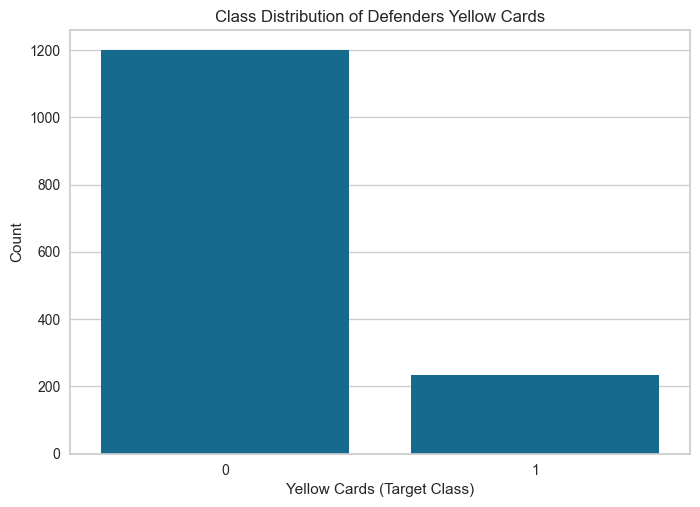

In [34]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [35]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 798, number of negative: 798
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14400
[LightGBM] [Info] Number of data points in the train set: 1596, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1433, 75)"
4,Transformed data shape,"(2026, 15)"
5,Transformed train set shape,"(1596, 15)"
6,Transformed test set shape,"(430, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [36]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4996,0.5366,0.5941,0.1821,0.2781,0.0379,0.0559,0.7980
qda,Quadratic Discriminant Analysis,0.5734,0.5295,0.4651,0.1823,0.2614,0.0356,0.0444,0.7700
lda,Linear Discriminant Analysis,0.5424,0.5235,0.5257,0.1836,0.2711,0.0398,0.0531,0.7210
ridge,Ridge Classifier,0.5444,0.5218,0.5199,0.1827,0.2691,0.0382,0.0513,0.7670
lr,Logistic Regression,0.5434,0.5213,0.5199,0.1824,0.2687,0.0375,0.0504,1.1910
knn,K Neighbors Classifier,0.4985,0.5101,0.5107,0.1629,0.2469,0.0005,0.0051,1.4710
gbc,Gradient Boosting Classifier,0.7967,0.5060,0.1169,0.2327,0.1518,0.0552,0.0588,1.1270
svm,SVM - Linear Kernel,0.4995,0.5017,0.4879,0.1571,0.2369,-0.0105,-0.0080,0.9040
xgboost,Extreme Gradient Boosting,0.7818,0.5005,0.0798,0.1601,0.1045,-0.0017,-0.0022,0.8710
dummy,Dummy Classifier,0.8365,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0490


In [37]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

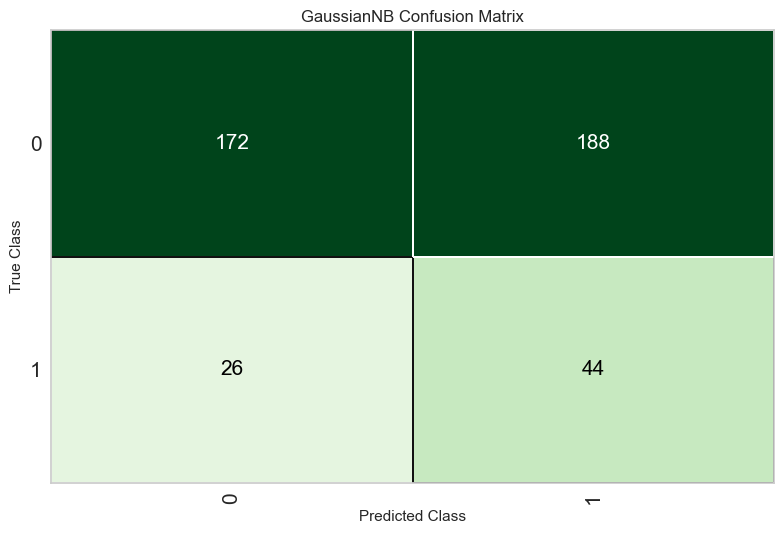

In [38]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [39]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3168,0.5105,0.8824,0.1829,0.3030,0.0336,0.0811
1,0.2574,0.4167,0.7647,0.1548,0.2574,-0.0313,-0.0805
2,0.2871,0.5028,0.7647,0.1605,0.2653,-0.0179,-0.0421
3,0.3100,0.4706,0.7647,0.1667,0.2737,-0.0076,-0.0167
4,0.3500,0.6815,0.8750,0.1818,0.3011,0.0492,0.1089
5,0.2000,0.4085,0.6875,0.1279,0.2157,-0.0741,-0.2170
6,0.3100,0.6347,0.9375,0.1807,0.3030,0.0475,0.1249
7,0.2600,0.5439,0.8750,0.1628,0.2745,0.0064,0.0189
8,0.3300,0.6376,1.0000,0.1928,0.3232,0.0751,0.1975


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [40]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [41]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          min_child_we

## MID


yellow_cards
0    1225
1     237
Name: count, dtype: int64


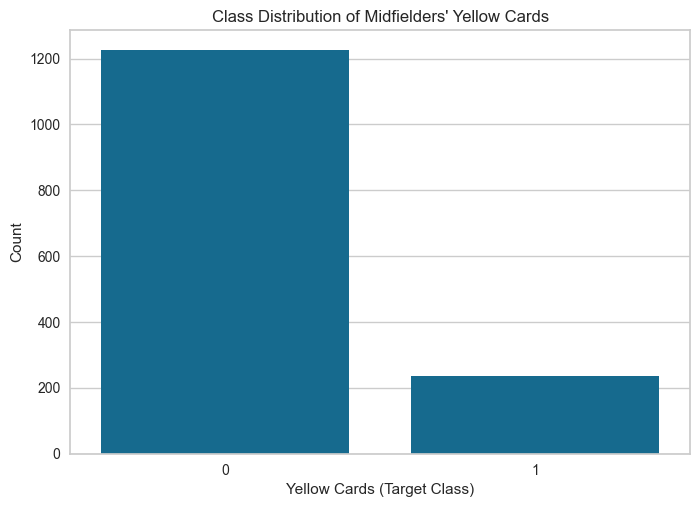

In [42]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [43]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 816, number of negative: 816
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.211847 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14681
[LightGBM] [Info] Number of data points in the train set: 1632, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1462, 75)"
4,Transformed data shape,"(2071, 15)"
5,Transformed train set shape,"(1632, 15)"
6,Transformed test set shape,"(439, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [44]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.5348,0.5546,0.5603,0.1907,0.2835,0.0537,0.0675,1.0500
nb,Naive Bayes,0.4458,0.5519,0.6577,0.1773,0.2791,0.0312,0.0461,0.7090
rf,Random Forest Classifier,0.7908,0.5391,0.0540,0.1387,0.0758,-0.0165,-0.0180,1.0510
lightgbm,Light Gradient Boosting Machine,0.7938,0.5330,0.0489,0.1375,0.0702,-0.0165,-0.0183,1.3790
xgboost,Extreme Gradient Boosting,0.7947,0.5312,0.0607,0.1578,0.0857,-0.0031,-0.0034,1.5760
lr,Logistic Regression,0.5445,0.5285,0.5408,0.1880,0.2776,0.0498,0.0647,1.6110
lda,Linear Discriminant Analysis,0.5396,0.5281,0.5408,0.1867,0.2762,0.0470,0.0603,1.2140
ridge,Ridge Classifier,0.5396,0.5279,0.5408,0.1867,0.2762,0.0470,0.0603,0.9070
et,Extra Trees Classifier,0.7997,0.5184,0.0724,0.1923,0.1040,0.0170,0.0199,1.1820
knn,K Neighbors Classifier,0.5024,0.5171,0.4985,0.1643,0.2467,0.0032,0.0016,1.1190


In [45]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [46]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4272,0.4795,0.5882,0.1613,0.2532,-0.0080,-0.0124
1,0.4951,0.5561,0.5882,0.1818,0.2778,0.0343,0.0484
2,0.4951,0.5219,0.6471,0.1930,0.2973,0.0577,0.0838
3,0.4412,0.5974,0.7500,0.1846,0.2963,0.0595,0.1011
4,0.6275,0.6904,0.6250,0.2381,0.3448,0.1522,0.1869
5,0.4804,0.5472,0.7500,0.1967,0.3117,0.0840,0.1337
6,0.4020,0.4593,0.6250,0.1538,0.2469,-0.0065,-0.0110
7,0.5000,0.5578,0.5882,0.1852,0.2817,0.0377,0.0527
8,0.5000,0.5509,0.5882,0.1852,0.2817,0.0377,0.0527


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [47]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [48]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          n_jobs=None,

## FWD


yellow_cards
0    409
1     50
Name: count, dtype: int64


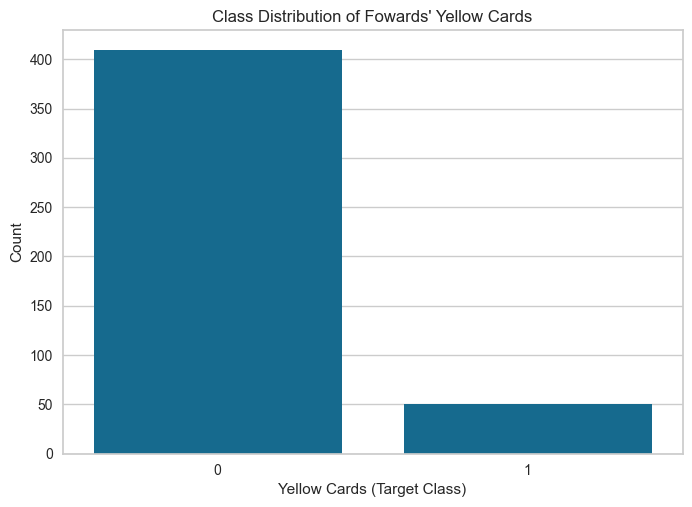

In [49]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [50]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 272, number of negative: 272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7913
[LightGBM] [Info] Number of data points in the train set: 544, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(459, 75)"
4,Transformed data shape,"(682, 15)"
5,Transformed train set shape,"(544, 15)"
6,Transformed test set shape,"(138, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [51]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8723,0.5137,0.0250,0.1000,0.0400,0.0035,0.0083,0.4810
rf,Random Forest Classifier,0.8565,0.5069,0.0583,0.1500,0.0800,0.0187,0.0253,0.5990
dummy,Dummy Classifier,0.8910,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4090
xgboost,Extreme Gradient Boosting,0.8380,0.4906,0.0500,0.0667,0.0571,-0.0185,-0.0198,0.6030
ada,Ada Boost Classifier,0.7974,0.4858,0.1750,0.1083,0.1330,0.0272,0.0276,0.4960
gbc,Gradient Boosting Classifier,0.8255,0.4670,0.0917,0.0667,0.0730,-0.0104,-0.0110,0.6360
lightgbm,Light Gradient Boosting Machine,0.8442,0.4624,0.1167,0.1000,0.1016,0.0287,0.0288,0.6520
dt,Decision Tree Classifier,0.7446,0.4392,0.0500,0.0310,0.0382,-0.0990,-0.1036,0.4260
knn,K Neighbors Classifier,0.5325,0.4322,0.3167,0.0821,0.1287,-0.0526,-0.0775,0.5990
nb,Naive Bayes,0.5580,0.4239,0.3333,0.0855,0.1347,-0.0406,-0.0563,0.5630


In [52]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [53]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8788,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.4688,0.4080,0.3333,0.0625,0.1053,-0.0625,-0.1072
2,0.9062,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.5938,0.4770,0.3333,0.0833,0.1333,-0.0196,-0.0277
4,0.6562,0.8103,1.0000,0.2143,0.3529,0.2348,0.3647
5,0.5938,0.4770,0.3333,0.0833,0.1333,-0.0196,-0.0277
6,0.6250,0.5714,0.5000,0.1667,0.2500,0.0769,0.0976
7,0.5625,0.6429,0.7500,0.1875,0.3000,0.1250,0.1890
8,0.8750,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [54]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [55]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=True, ccp_alpha=0.0,
                                